# Étape 1 : Analyse Exploratoire des Données (Python)

• Charger le dataset avec pandas et identifier les types de variables : continues vs discrètes.

• Analyser les statistiques descriptives : moyenne, médiane, min, max, écart-type.
Visualiser les données :

• Histogrammes et boxplots pour les ventes et montants des produits.

• Bar charts pour le nombre de clients ayant accepté chaque campagne.
Vérifier les anomalies, valeurs manquantes et doublons.

Interpréter les résultats pour tirer des insights initiaux sur les clients et campagnes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('data-69d3709338fdb705334215.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,11,4,0,0,0,0,0,0,0,USA
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,0,0,0,0,0,0,0,Spain
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,5,8,0,0,0,0,0,0,0,Spain
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,10,3,0,0,0,0,0,0,0,India


In [3]:
#  Types des variables continues vs discrètes:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntBakedProds        2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
'''
------               --------------  -----  ---------- ----- ----------  ----- ----------
 0   ID                  : identifiant de chaque clients
 1   Year_Birth (discrèt)       : année de naissance
 2   Education (discrèt)        : niveau d'études
 3   Marital_Status (discrèt)   : situation familiale (Single, Married…)
 4    Income (continue)         : revenu annuel du client
 5   Kidhome (discrèt)          : nombre d'enfants
 6   Teenhome (discrèt )        : nombre d'adolescents (المراهقون)
 7   Dt_Customer (discrèt)      : date d'inscription
 8   Recency (discrèt)          : nombre de jours depuis le dernier achat
 9   MntWines (continue)        : dépenses en vin (bir الماحيا)
 10  MntFruits (continue)       : dépenses en fruits
 11  MntMeatProducts (continue) : dépenses en viande
 12  MntFishProducts (continue) : dépenses en poisson
 13  MntSweetProducts (continue): dépenses en sucreries
 14  MntBakedProds (continue)   : dépenses en produits de boulangerie
 15  NumDealsPurchases (discrèt): achats en promotion
 16  NumWebPurchases (discrèt)  : achats en ligne
 17  NumCatalogPurchases(discrèt): achats via catalogue
 18  NumStorePurchases (discrèt): achats en magasin
 19  NumWebVisitsMonth (discrèt): nombre de visites du site par mois
 20  AcceptedCmp1  (discrèt)    : 
   |        |        |        |
 24  AcceptedCmp5  (discrèt)    : 
 25  Response  (discrèt)        : réponse à la dernière campagne
 26  Complain  (discrèt)        : indique si le client a fait une réclamation
 27  Country (discrètes) : pays du client
'''

"\n------               --------------  -----  ---------- ----- ----------  ----- ----------\n 0   ID                  : identifiant de chaque clients\n 1   Year_Birth (discrèt)       : année de naissance\n 2   Education (discrèt)        : niveau d'études\n 3   Marital_Status (discrèt)   : situation familiale (Single, Married…)\n 4    Income (continue)         : revenu annuel du client\n 5   Kidhome (discrèt)          : nombre d'enfants\n 6   Teenhome (discrèt )        : nombre d'adolescents (المراهقون)\n 7   Dt_Customer (discrèt)      : date d'inscription\n 8   Recency (discrèt)          : nombre de jours depuis le dernier achat\n 9   MntWines (continue)        : dépenses en vin (bir الماحيا)\n 10  MntFruits (continue)       : dépenses en fruits\n 11  MntMeatProducts (continue) : dépenses en viande\n 12  MntFishProducts (continue) : dépenses en poisson\n 13  MntSweetProducts (continue): dépenses en sucreries\n 14  MntBakedProds (continue)   : dépenses en produits de boulangerie\n 15  

In [5]:
# Analyser les statistiques descriptives:
statis_desc = []
for var in df.select_dtypes(include='number').columns:
    if var == 'ID':
        continue
    statis_desc.append({
        'variable': var,
        'moyenne': df[var].mean(),
        'médiane': df[var].median(),
        'min': df[var].min(),
        'max': df[var].max(),
        'écart-type': df[var].std()
    })
statis_desc_df = pd.DataFrame(statis_desc)
statis_desc_df

,variable,moyenne,médiane,min,max,écart-type
0,Year_Birth,1968.805804,1970.0,1893.0,1996.0,11.984069
1,Income,52247.251354,51381.5,1730.0,666666.0,25173.076661
2,Kidhome,0.444196,0.0,0.0,2.0,0.538398
3,Teenhome,0.506250,0.0,0.0,2.0,0.544538
4,Recency,49.109375,49.0,0.0,99.0,28.962453
5,MntWines,303.935714,173.5,0.0,1493.0,336.597393
6,MntFruits,26.302232,8.0,0.0,199.0,39.773434
7,MntMeatProducts,166.950000,67.0,0.0,1725.0,225.715373
8,MntFishProducts,37.525446,12.0,0.0,259.0,54.628979
9,MntSweetProducts,27.062946,8.0,0.0,263.0,41.280498


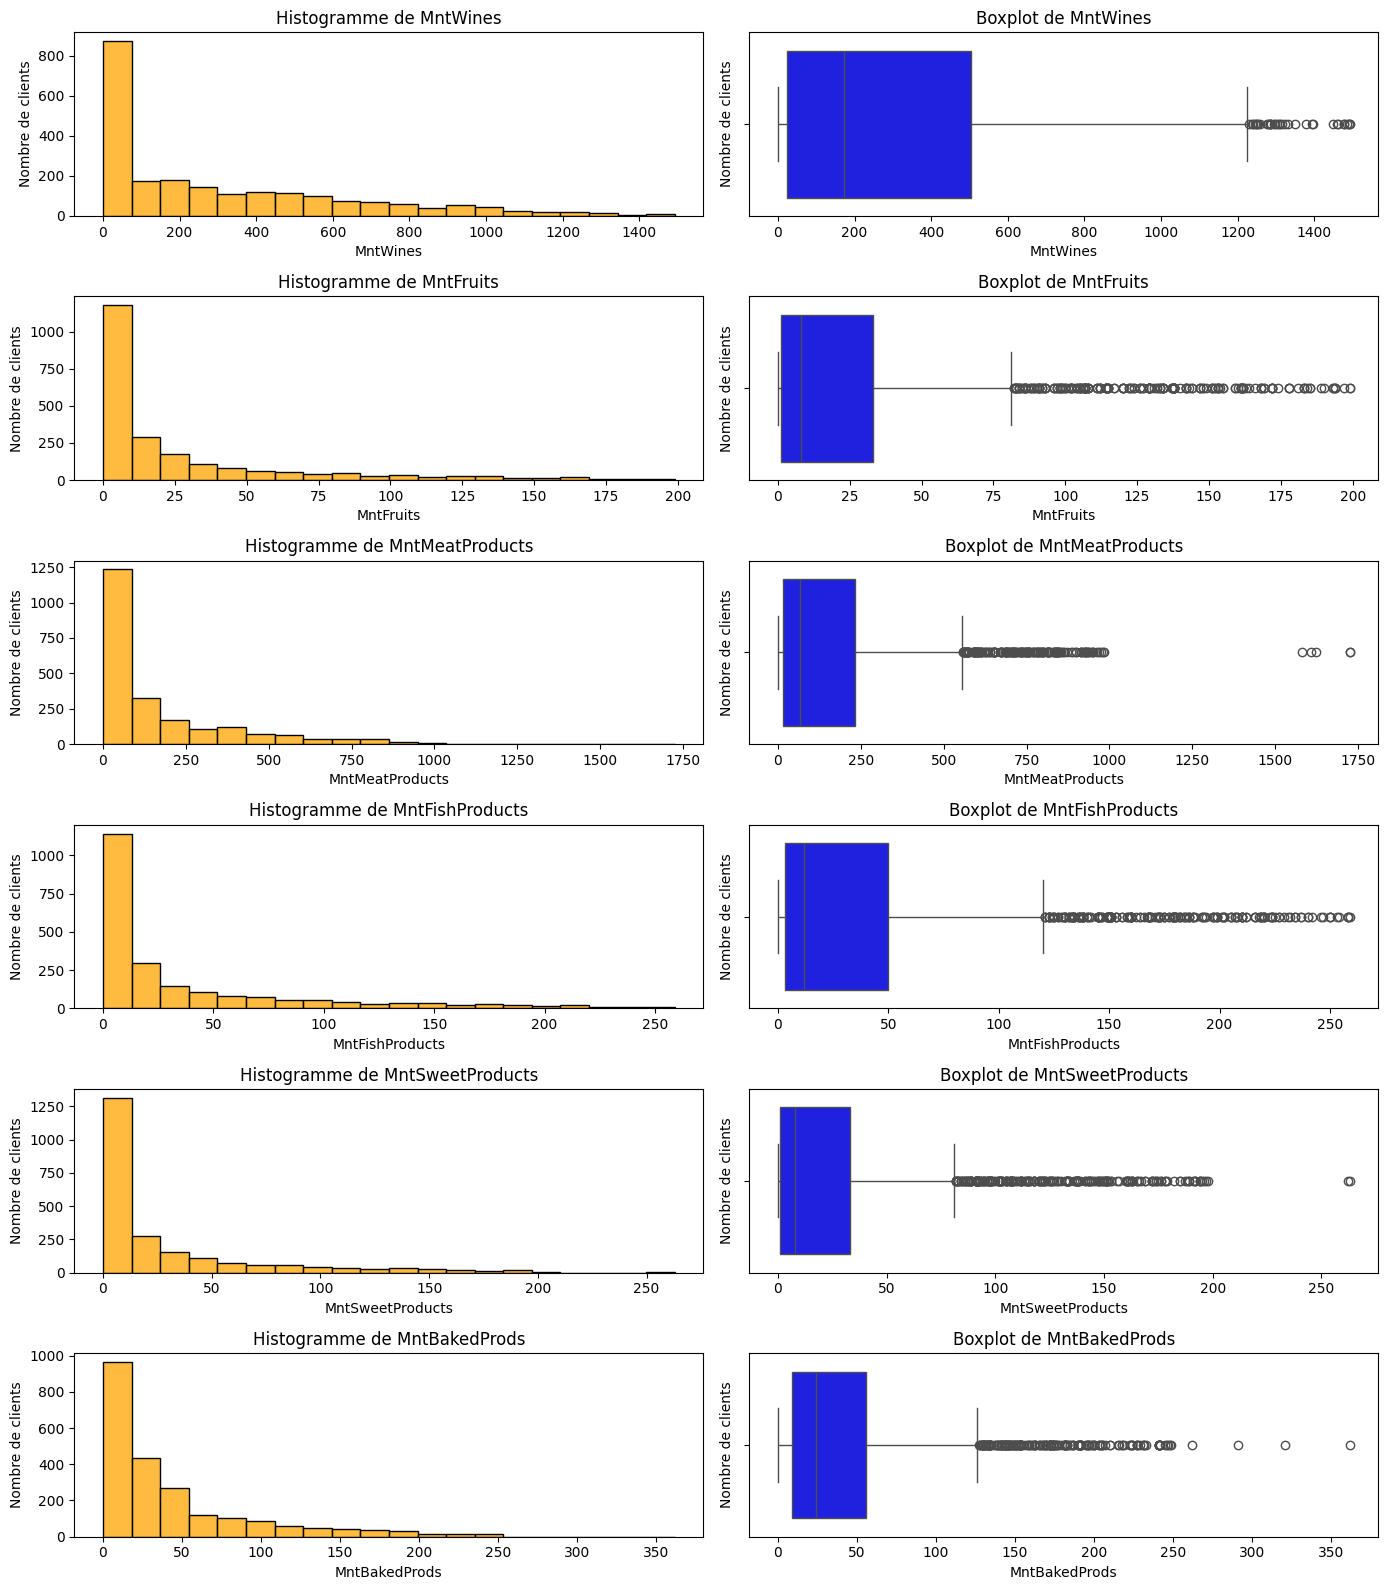

In [6]:
ventes = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']
plt.figure(figsize=(14,  4*4))
for i, v in enumerate(ventes): # i = index /   v= value of ventes
    # Histogrammes
    plt.subplot(6, 2, 2*i + 1)
    sns.histplot(df[v], bins=20, color='orange')
    plt.title(f'Histogramme de {v}')
    plt.xlabel(v)
    plt.ylabel('Nombre de clients')

    # boxplots
    plt.subplot(6, 2, 2*i+2)
    sns.boxplot(x=df[v], color='blue')
    plt.title(f'Boxplot de {v}')
    plt.xlabel(v)
    plt.ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

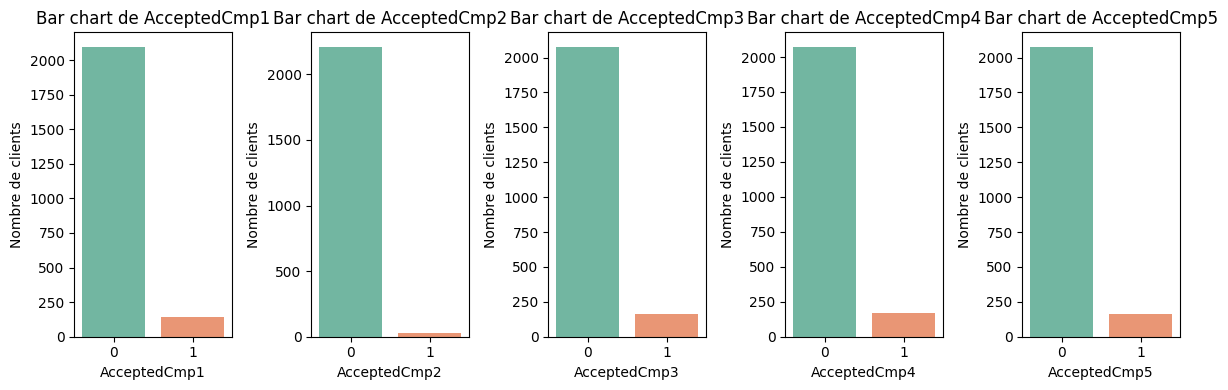

In [7]:
campagnes = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
plt.figure(figsize=(12, 4))
for i, v in enumerate(campagnes): # i = index /   v= value of ventes
    # Bar chart
    counts = df[v].value_counts()
    plt.subplot(1, 5, i + 1)
    sns.barplot(x=counts.index, y=counts.values,  hue=counts.index, palette='Set2', legend=False)
    plt.title(f'Bar chart de {v}')
    plt.xlabel(v)
    plt.ylabel('Nombre de clients')

plt.tight_layout()
plt.show()

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntBakedProds           0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [9]:
print(df.duplicated().sum())

0


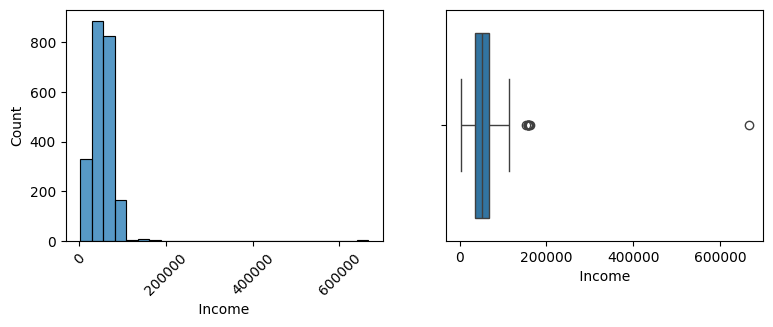

In [10]:
# Analyse de la variable "Income"
# histogramme
plt.figure(figsize=(9,3))
plt.subplot(1,2,1)
sns.histplot(df[' Income '],bins=25)
plt.xticks(rotation=45)
# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df[' Income '])
plt.show()


In [3]:
# Total spending:
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']].sum(axis='columns')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Spending
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,1,0,0,0,0,0,1,0,Spain,1190
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,5,0,0,0,0,1,1,0,Canada,577
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,2,0,0,0,0,0,0,0,USA,251
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,7,0,0,0,0,0,0,0,Australia,11
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,7,1,0,0,0,0,1,0,Spain,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,4,0,0,0,0,0,0,0,USA,689
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,8,0,0,0,0,0,0,0,Spain,55
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,8,0,0,0,0,0,0,0,Spain,309
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,3,0,0,0,0,0,0,0,India,1383


<Axes: xlabel='Total_Spending'>

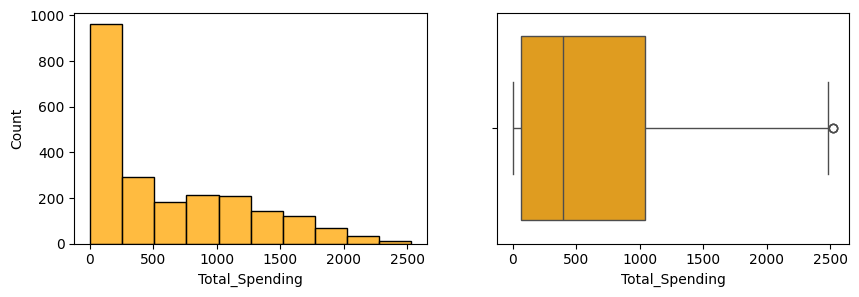

In [12]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.histplot(df['Total_Spending'], bins=10, color='orange')
plt.subplot(1,2,2)
sns.boxplot(x=df['Total_Spending'], color='orange')


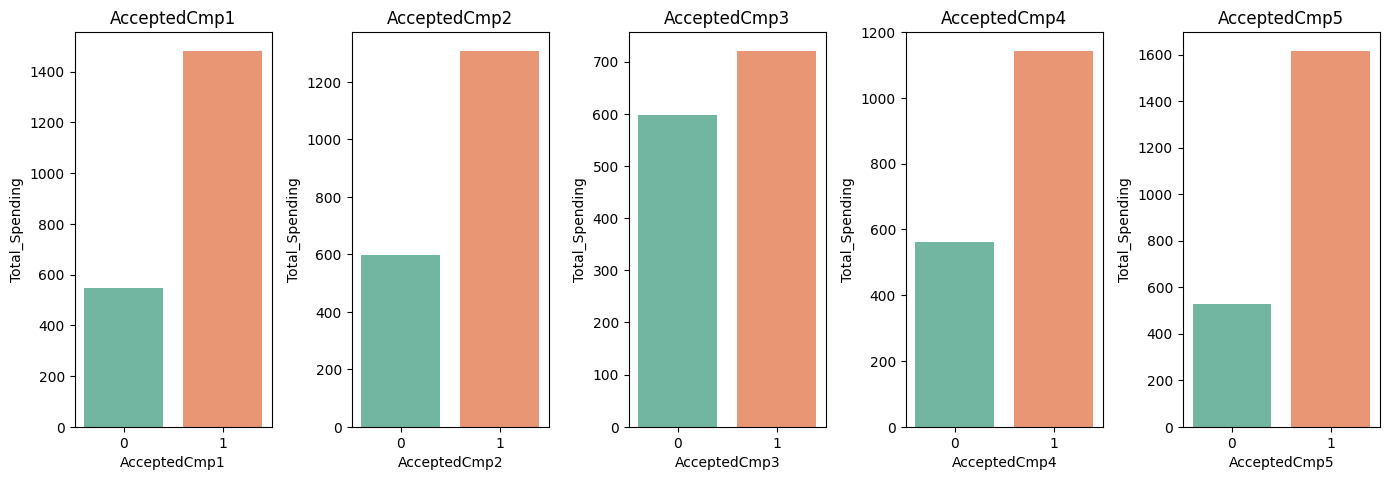

In [13]:
# Total spending par companges:
campagnes = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
plt.figure(figsize=(14,9))
for i, A in enumerate(campagnes):
    X= df.groupby(A)['Total_Spending'].mean()
    plt.subplot(2, 5, i + 1)
    sns.barplot(x=X.index, y=X.values,  hue=X.index, palette='Set2', legend=False)
    plt.title(A)
    plt.xlabel(A)
    plt.ylabel('Total_Spending')
plt.tight_layout()
plt.show()

In [14]:
# plt.figure(figsize=(9,3))
# plt.subplot(1,2,1)
# sns.heatmap(dt[' Income '], annot=True, cmap='coolwarm', center=0)

# Étape 2 : Tests Statistiques

• Vérifier l’impact des campagnes sur les ventes :

    t-test ou ANOVA pour comparer les montants moyens des ventes.
    Chi² pour les variables catégorielles (ex. campagne acceptée vs pays).
• Explorer les corrélations entre les variables démographiques et le comportement d’achat.

• Interpréter les p-values pour identifier les facteurs significatifs.

In [15]:
from scipy.stats import ttest_ind
# H0 : Il n’y a pas de différence significative entre les deux groupes
# H1 : Les clients ayant accepté la campagne achètent plus

group_accepted = df[df['AcceptedCmp5'] == 1]['Total_Spending']
group_not_accepted = df[df['AcceptedCmp5'] == 0]['Total_Spending']

t_stat, p_value = ttest_ind(group_accepted, group_not_accepted)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Il existe une différence significative → la campagne a un impact.")
else:
    print("Pas de différence significative → pas d’impact واضح.")

t-statistic: 25.19419971325456
p-value: 1.631828328804914e-123
Il existe une différence significative → la campagne a un impact.


<Axes: >

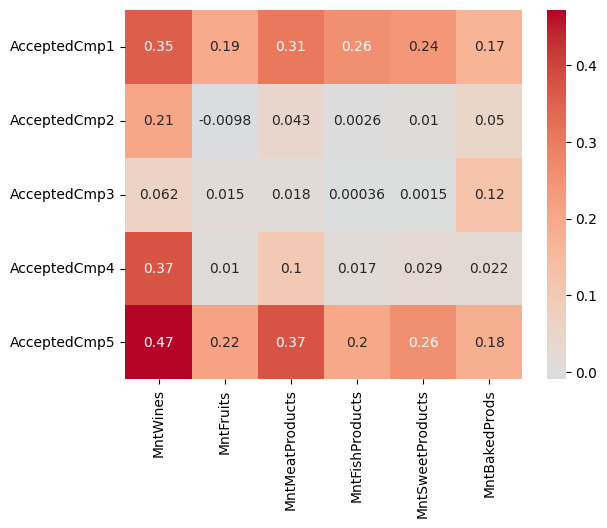

In [16]:
#  Vérification de l’impact des campagnes sur les ventes :
numeric_cols = df.select_dtypes(include='number')

corr = numeric_cols.corr()
campagnes = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
ventes = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']

impact = corr.loc[campagnes, ventes]
sns.heatmap(impact, annot=True, cmap='coolwarm', center=0)


In [17]:
from scipy.stats import chi2_contingency

campagnes = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
table = pd.crosstab(df['Country'], df['AcceptedCmp1'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.8697483318113399


<Axes: xlabel='Country'>

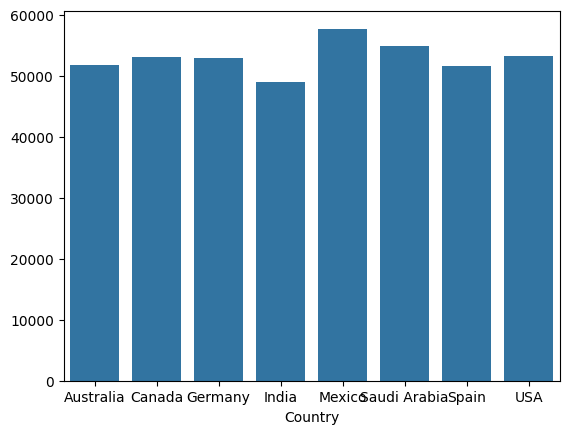

In [21]:
# MOYENNE INCOME BY COUNTRY:
MOY = df.groupby('Country')[' Income '].mean()
sns.barplot( x= MOY.index, y= MOY.values)

In [26]:
df['Country'].value_counts()

Country
Spain           1095
Saudi Arabia     337
Canada           268
Australia        160
India            148
Germany          120
USA              109
Mexico             3
Name: count, dtype: int64